In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.special import logsumexp
from matplotlib import gridspec


In [2]:

titles = ['Exp_1_live_lowpH', 
          'Exp_2_reduced_live_lowpH', 
          'Exp_3_time-limited_lowpH',
          'Exp_4_live_highpH',
          'Exp_5_time-limited_highpH', 
          'Exp_6_BB_time-limited_highpH', 
          'Exp_7_low-salinity_time-limited', 
          'Exp_8_BB_low-salinity_time-limited']

files = len(titles)*['mcmc_res.csv'] 


results=[]

for title, file in zip(titles, files):
    input = f"grid_likelihood_outputs/{title}/{file}"
    df = pd.read_csv(input)
    results.append(df)





In [3]:
for title, df_res in zip(titles, results):
    mu = df_res['mu'].to_numpy()[-9000:]
    acceptance = mu[1:] != mu[:-1]
    print(f"{title}: {np.mean(acceptance)}, len: {len(mu)}")


Exp_1_live_lowpH: 0.5719524391599067, len: 9000
Exp_2_reduced_live_lowpH: 0.5762862540282253, len: 9000
Exp_3_time-limited_lowpH: 0.7417490832314702, len: 9000
Exp_4_live_highpH: 0.5712856984109346, len: 9000
Exp_5_time-limited_highpH: 0.5977330814534948, len: 9000
Exp_6_BB_time-limited_highpH: 0.7357484164907212, len: 9000
Exp_7_low-salinity_time-limited: 0.5823980442271364, len: 9000
Exp_8_BB_low-salinity_time-limited: 0.7397488609845538, len: 9000


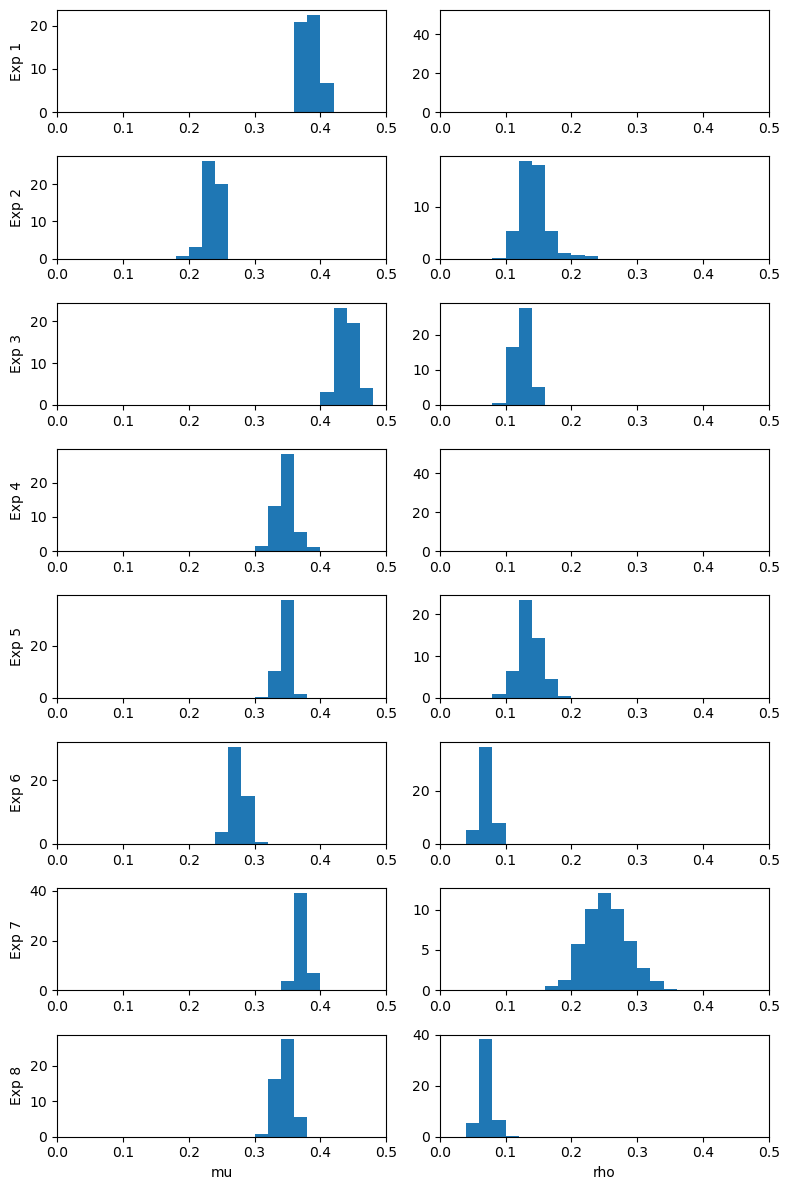

In [6]:
fig, axs = plt.subplots(nrows=len(titles), ncols=2, figsize=(8, 12))
x = np.linspace(0,1,51)
for title, df_res, ax in zip(titles, results, axs):
    ax[0].hist(df_res['mu'].to_numpy()[-9000:], density=True,bins=x)
    ax[1].hist(df_res['rho'].to_numpy()[-9000:], density=True,bins=x)
    ax[0].set_ylabel(" ".join(title.split("_", 2)[:2]))


[axi.set_xlim(0,.5) for axi in axs.flatten()]
axs[-1][0].set_xlabel('mu')
axs[-1][1].set_xlabel('rho')

plt.tight_layout()
plt.savefig('mcmc_comparison.png',bbox_inches='tight',dpi=900)
